<a href="https://colab.research.google.com/github/Sibitenda/PhDumu/blob/main/big_data/week5_ML_bigdata1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 Advanced Pipeline Notebook
## BigQuery + Data Audit + Provenance + Governance + ML

In [2]:
!pip install google-cloud-bigquery pandas scikit-learn --quiet

In [3]:
from google.colab import auth
auth.authenticate_user()

# PROJECT_ID = "your-project-id"
PROJECT_ID = "bigdata1-491608"  # put yours


from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

import pandas as pd
import numpy as np


## Data Acquisition

In [8]:
query = """
SELECT
  country,
  city,
  value
FROM
  `bigquery-public-data.openaq.global_air_quality`
WHERE
  country = 'UG'
  AND value IS NOT NULL
LIMIT 5000
"""

df = client.query(query).to_dataframe()
df.head()

,country,city,value
0,UG,Kampala,50.0
1,UG,Kampala,-999.0
2,UG,Kampala,31.0
3,UG,Kampala,19.0
4,UG,Kampala,51.0


## Data Audit

In [9]:
def data_audit(df):
    print("Shape:", df.shape)
    print("\nMissing:\n", df.isnull().sum())
    print("\nTypes:\n", df.dtypes)
    print("\nUnique:\n", df.nunique())
    display(df.describe(include='all'))

data_audit(df)

Shape: (509, 3)

Missing:
 country    0
city       0
value      0
dtype: int64

Types:
 country     object
city        object
value      float64
dtype: object

Unique:
 country     1
city        2
value      66
dtype: int64


,country,city,value
count,509,509,509.000000
unique,1,2,NaN
top,UG,Kampala,NaN
freq,509,483,NaN
mean,NaN,NaN,-179.444008
std,NaN,NaN,423.448994
min,NaN,NaN,-999.000000
25%,NaN,NaN,21.000000
50%,NaN,NaN,31.000000
75%,NaN,NaN,40.000000


## Cleaning

In [10]:
df_clean = df.dropna()
df_clean = df_clean[df_clean['value'] > 0]
df_clean.head()

,country,city,value
0,UG,Kampala,50.0
2,UG,Kampala,31.0
3,UG,Kampala,19.0
4,UG,Kampala,51.0
5,UG,Kampala,36.0


## Provenance

In [11]:
log = []

def log_step(name, df):
    log.append({"step": name, "rows": df.shape[0], "cols": df.shape[1]})

log_step("raw", df)
log_step("cleaned", df_clean)

pd.DataFrame(log)

,step,rows,cols
0,raw,509,3
1,cleaned,402,3


In [13]:
# 1. BASIC OVERVIEW
print("\n===== BASIC OVERVIEW =====")
print("Shape:", df_clean.shape)

print("\nData Types:")
print(df_clean.dtypes)

print("\nSummary Statistics:")
display(df_clean.describe())

print("\nUnique Values per Column:")
print(df_clean.nunique())



===== BASIC OVERVIEW =====
Shape: (402, 4)

Data Types:
country       object
city          object
value        float64
log_value    float64
dtype: object

Summary Statistics:


,value,log_value
count,402.000000,402.000000
mean,38.696517,3.590878
std,15.048134,0.351547
min,17.000000,2.833213
25%,29.000000,3.367296
50%,35.000000,3.555348
75%,46.000000,3.828641
max,109.000000,4.691348



Unique Values per Column:
country       1
city          2
value        65
log_value    65
dtype: int64


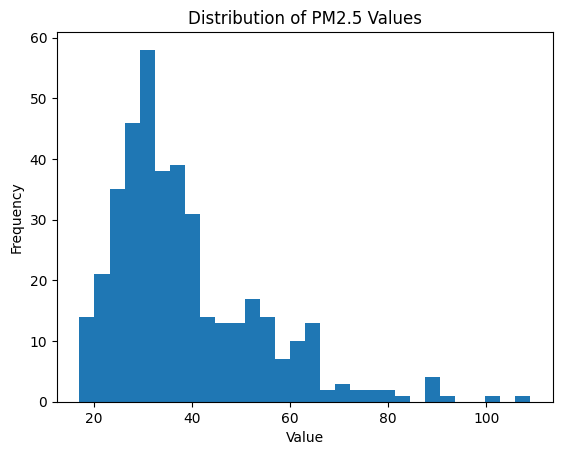

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_clean['value'], bins=30)
plt.title("Distribution of PM2.5 Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

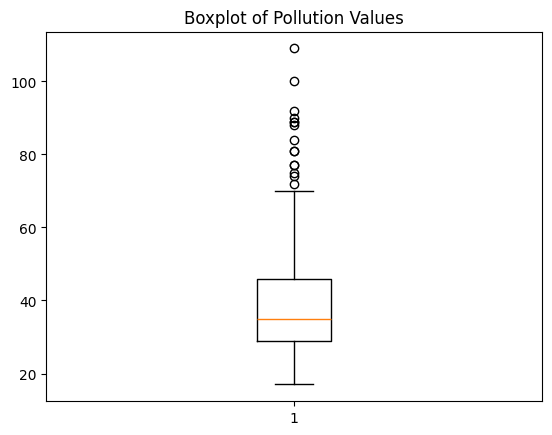

In [15]:
# 4. BOXPLOT (OUTLIER DETECTION)

plt.figure()
plt.boxplot(df_clean['value'])
plt.title("Boxplot of Pollution Values")
plt.show()

In [16]:
# 5. CITY REPRESENTATION (BIAS CHECK)
print("\n===== CITY REPRESENTATION =====")
city_counts = df_clean['city'].value_counts()

print("\nTop 10 Cities by Number of Records:")
print(city_counts.head(10))


===== CITY REPRESENTATION =====

Top 10 Cities by Number of Records:
city
Kampala    376
N/A         26
Name: count, dtype: int64


In [17]:
# 6. CITY-LEVEL AGGREGATION
print("\n===== CITY AVERAGE POLLUTION =====")

city_avg = (
    df_clean
    .groupby('city')['value']
    .mean()
    .sort_values(ascending=False)
)

print("\nTop 10 Most Polluted Cities:")
print(city_avg.head(10))



===== CITY AVERAGE POLLUTION =====

Top 10 Most Polluted Cities:
city
N/A        41.384615
Kampala    38.510638
Name: value, dtype: float64


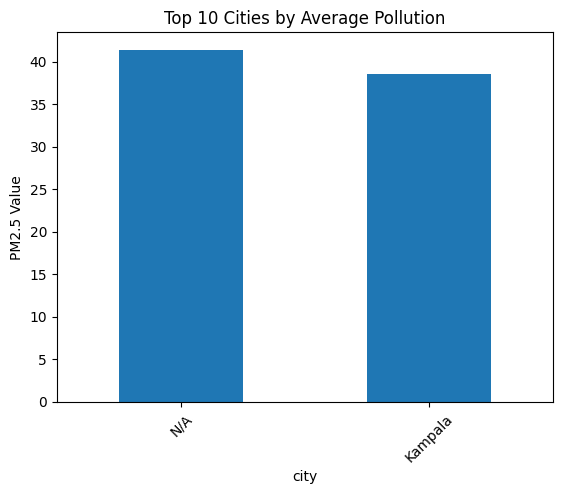

In [18]:
# 7. VISUALIZE TOP CITIES

top_cities = city_avg.head(10)

plt.figure()
top_cities.plot(kind='bar')
plt.title("Top 10 Cities by Average Pollution")
plt.ylabel("PM2.5 Value")
plt.xticks(rotation=45)
plt.show()

In [48]:
# 8. FEATURE ENGINEERING (FOR ML)
# ======================================
import numpy as np

df_clean['log_value'] = np.log(df_clean['value'])

print("\nFeature Engineering Added: log_value")
display(df_clean.head())


Feature Engineering Added: log_value


,country,city,value,log_value,label,cluster
0,UG,Kampala,50.0,3.912023,1,0
2,UG,Kampala,31.0,3.433987,0,1
3,UG,Kampala,19.0,2.944439,0,1
4,UG,Kampala,51.0,3.931826,1,0
5,UG,Kampala,36.0,3.583519,1,1


In [20]:
# 9. CORRELATION ANALYSIS
print("\n===== CORRELATION MATRIX =====")
display(df_clean[['value', 'log_value']].corr())



===== CORRELATION MATRIX =====


,value,log_value
value,1.00000,0.97363
log_value,0.97363,1.00000


In [21]:
# 10. DATA INSIGHT SUMMARY (AUTO PRINT)
print("\n===== QUICK INSIGHTS =====")

print("- Dataset contains", df_clean.shape[0], "records")
print("- Number of cities:", df_clean['city'].nunique())

print("- Max pollution value:", df_clean['value'].max())
print("- Min pollution value:", df_clean['value'].min())

print("- Mean pollution:", df_clean['value'].mean())

print("\nPotential Issues:")
print("- Unequal city representation (bias)")
print("- Possible outliers in pollution values")
print("- Skewed distribution (check histogram)")


===== QUICK INSIGHTS =====
- Dataset contains 402 records
- Number of cities: 2
- Max pollution value: 109.0
- Min pollution value: 17.0
- Mean pollution: 38.69651741293532

Potential Issues:
- Unequal city representation (bias)
- Possible outliers in pollution values
- Skewed distribution (check histogram)


## Feature Engineering

In [26]:
# FEATURE ENGINEERING
df_clean['log_value'] = np.log(df_clean['value'])

# Create labels (binary classification)
df_clean['label'] = (df_clean['value'] > df_clean['value'].median()).astype(int)

X = df_clean[['value', 'log_value']]
y = df_clean['label']

## Supervised Learning

In [28]:
# TRAIN / VALIDATION / TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("\nTrain:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)


Train: (281, 2) Validation: (60, 2) Test: (61, 2)


In [29]:
# MODEL 1: RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

val_preds_rf = rf_model.predict(X_val)


# MODEL 2: LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

val_preds_lr = lr_model.predict(X_val)


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, preds, model_name):
    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_true, preds))
    print("Precision:", precision_score(y_true, preds))
    print("Recall:", recall_score(y_true, preds))
    print("F1 Score:", f1_score(y_true, preds))


# VALIDATION RESULTS
evaluate(y_val, val_preds_rf, "Random Forest (Validation)")
evaluate(y_val, val_preds_lr, "Logistic Regression (Validation)")


===== Random Forest (Validation) =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

===== Logistic Regression (Validation) =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [31]:
# CROSS-VALIDATION

from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf_model, X, y, cv=5)
lr_cv = cross_val_score(lr_model, X, y, cv=5)

print("\nRF Cross-validation mean:", rf_cv.mean())
print("LR Cross-validation mean:", lr_cv.mean())



RF Cross-validation mean: 1.0
LR Cross-validation mean: 1.0


In [32]:
# FINAL TEST EVALUATION
test_preds_rf = rf_model.predict(X_test)
test_preds_lr = lr_model.predict(X_test)

evaluate(y_test, test_preds_rf, "Random Forest (Test)")
evaluate(y_test, test_preds_lr, "Logistic Regression (Test)")


===== Random Forest (Test) =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

===== Logistic Regression (Test) =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [33]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix

print("\nConfusion Matrix (RF):\n", confusion_matrix(y_test, test_preds_rf))
print("\nConfusion Matrix (LR):\n", confusion_matrix(y_test, test_preds_lr))


Confusion Matrix (RF):
 [[24  0]
 [ 0 37]]

Confusion Matrix (LR):
 [[24  0]
 [ 0 37]]


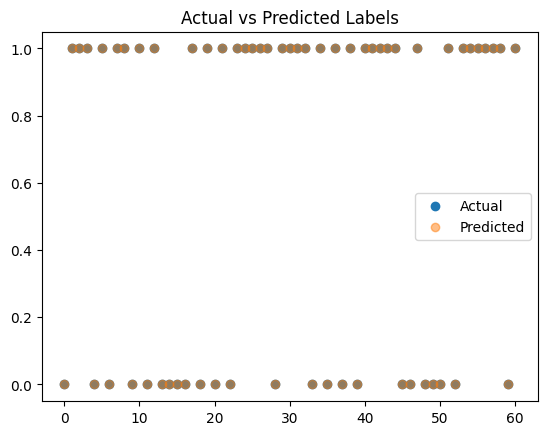

In [36]:
plt.figure()
plt.scatter(range(len(y_test)), y_test, label='Actual')
plt.scatter(range(len(test_preds_rf)), test_preds_rf, alpha=0.5, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Labels")
plt.show()

In [34]:
# FEATURE IMPORTANCE (EXPLAINABILITY)
importance = rf_model.feature_importances_

print("\nFeature Importance:")
for i, col in enumerate(X.columns):
    print(f"{col}: {importance[i]}")


Feature Importance:
value: 0.49
log_value: 0.51


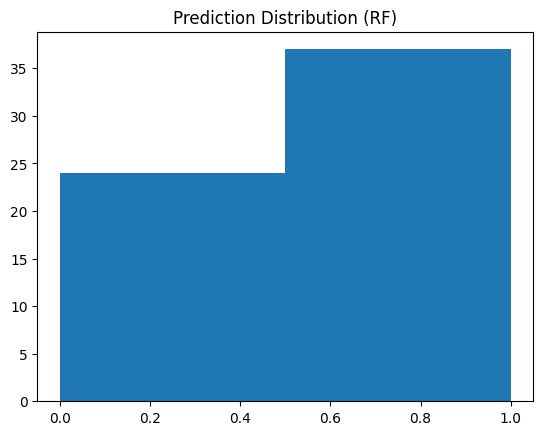

In [37]:
plt.figure()
plt.hist(test_preds_rf, bins=2)
plt.title("Prediction Distribution (RF)")
plt.show()

In [35]:
# BIAS CHECK (VERY IMPORTANT)

print("\n===== BIAS CHECK =====")

city_distribution = df_clean['city'].value_counts(normalize=True)
print("Top city dominance:\n", city_distribution.head(5))

print("\nLabel distribution:")
print(y.value_counts(normalize=True))


===== BIAS CHECK =====
Top city dominance:
 city
Kampala    0.935323
N/A        0.064677
Name: proportion, dtype: float64

Label distribution:
label
0    0.527363
1    0.472637
Name: proportion, dtype: float64


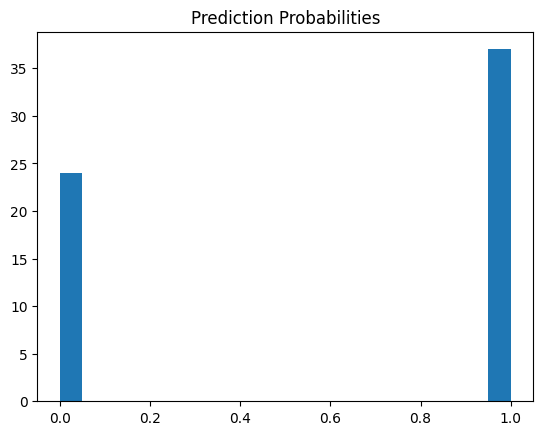

In [38]:
probs = rf_model.predict_proba(X_test)[:, 1]

plt.figure()
plt.hist(probs, bins=20)
plt.title("Prediction Probabilities")
plt.show()

In [39]:
df_test = X_test.copy()
df_test['city'] = df_clean.loc[X_test.index, 'city']
df_test['actual'] = y_test
df_test['predicted'] = test_preds_rf

city_accuracy = df_test.groupby('city').apply(
    lambda x: (x['actual'] == x['predicted']).mean()
)

print("\nAccuracy per city:")
print(city_accuracy.sort_values())


Accuracy per city:
city
Kampala    1.0
N/A        1.0
dtype: float64


/tmp/ipykernel_29960/2006663535.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  city_accuracy = df_test.groupby('city').apply(


In [40]:
df_test['error'] = df_test['actual'] != df_test['predicted']

city_error = df_test.groupby('city')['error'].mean()

print("\nError rate per city:")
print(city_error.sort_values(ascending=False).head(10))


Error rate per city:
city
Kampala    0.0
N/A        0.0
Name: error, dtype: float64


In [41]:
print("\nLabel Distribution:")
print(y.value_counts(normalize=True))


Label Distribution:
label
0    0.527363
1    0.472637
Name: proportion, dtype: float64


In [42]:
rf_model_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model_balanced.fit(X_train, y_train)

balanced_preds = rf_model_balanced.predict(X_test)

evaluate(y_test, balanced_preds, "Balanced Random Forest")


===== Balanced Random Forest =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [43]:
from sklearn.utils import resample

# Combine data
train_data = pd.concat([X_train, y_train], axis=1)

# Separate classes
majority = train_data[train_data['label'] == 0]
minority = train_data[train_data['label'] == 1]

# Upsample minority
minority_upsampled = resample(minority, replace=True, n_samples=len(majority))

balanced_data = pd.concat([majority, minority_upsampled])

X_train_bal = balanced_data[['value', 'log_value']]
y_train_bal = balanced_data['label']

In [44]:
rf_model.fit(X_train_bal, y_train_bal)
new_preds = rf_model.predict(X_test)

evaluate(y_test, new_preds, "Resampled RF")


===== Resampled RF =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


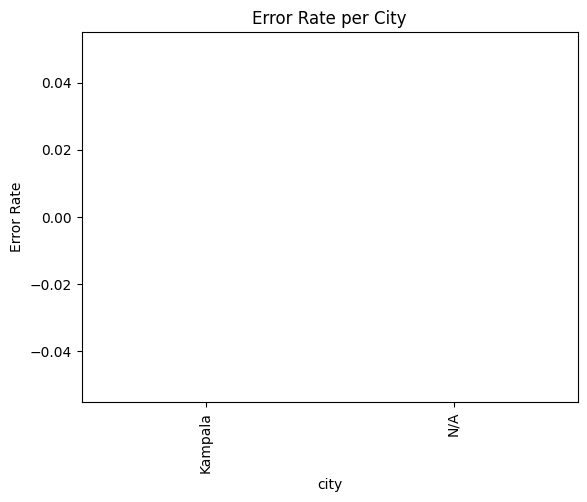

In [45]:
city_error.head(10).plot(kind='bar')
plt.title("Error Rate per City")
plt.ylabel("Error Rate")
plt.show()

In [51]:
from google.cloud import bigquery

dataset_id = f"{PROJECT_ID}.week5"

dataset = bigquery.Dataset(dataset_id)
dataset.location = "US"

dataset = client.create_dataset(dataset, exists_ok=True)

print("Dataset created:", dataset_id)

Dataset created: bigdata1-491608.week5


In [52]:
table_id = f"{PROJECT_ID}.week5.results"

job = client.load_table_from_dataframe(df_clean, table_id)
job.result()

print("Saved to BigQuery:", table_id)

Saved to BigQuery: bigdata1-491608.week5.results


## Unsupervised Learning

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3)
df_clean['cluster'] = kmeans.fit_predict(X)

score = silhouette_score(X, df_clean['cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.5989374207030064


## Save

In [ ]:
df_clean.to_csv("final_results.csv", index=False)
print("Saved!")